# 1. Importación

Carga de las librerías, del modelo final guardado por `03_model_training.ipynb` (`models/price_model.pkl`, `models/model_metadata.json`) y del test (`data/processed/listings_test.csv`). Este notebook no reentrena nada, parte de lo que ya quedó guardado.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
final_pipeline = joblib.load("/Users/yagocoll/Documents/Master/Airbnb/models/price_model.pkl")

with open("/Users/yagocoll/Documents/Master/Airbnb/models/model_metadata.json") as f:
    metadata = json.load(f)

test_df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_test.csv")
metadata["test_metrics"]

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': 134.90033565613476,
 'MAE': 52.21666524654111,
 'R2': 0.8585286462287347,
 'MAPE': 20.351604430099684}

## 2. Reconstruir predicciones

Mismos `feature_cols`/`target` que en el entrenamiento (guardados en `metadata`, no hay que volver a decidirlos a mano), para tener `y_test` y las predicciones disponibles para todo el análisis que sigue.

### 2.1 X e y de test

`metadata["feature_cols"]` ya tiene la lista exacta de columnas que espera el modelo, en el mismo orden y con el mismo criterio (identificadores y columnas de fuga ya excluidos desde `03_model_training.ipynb`). Las booleanas se convierten a `int`, igual que en el entrenamiento.

In [3]:
feature_cols = metadata["feature_cols"]
target_col = metadata["target"]

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

bool_cols = X_test.select_dtypes(include="bool").columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

X_test.shape

(2652, 66)

### 2.2 Función `evaluate`

No existe todavía en este notebook (es nuevo, no hereda nada de `03_model_training.ipynb`). Se define igual que en los dos notebooks anteriores, para mantener las mismas métricas en los tres.

In [4]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 2.3 Predecir

El modelo predice en escala `log1p(price)`; se deshace con `expm1` antes de evaluar nada.

In [5]:
pred = np.expm1(final_pipeline.predict(X_test))
residuals = pred - y_test.values

evaluate(y_test, pred, "Hist Gradient Boosting")

{'modelo': 'Hist Gradient Boosting',
 'RMSE': np.float64(134.90033565613476),
 'MAE': 52.21666524654111,
 'R2': 0.8585286462287347,
 'MAPE': np.float64(20.351604430099684)}

Coincide exactamente con `metadata["test_metrics"]` (RMSE=134.90€, MAE=52.22€, R²=0.86, MAPE=20.35%): el modelo cargado predice igual que cuando se guardó, así que se puede seguir con el análisis de errores con confianza en que no hay ninguna discrepancia por el camino.

## 3. Predicción vs. realidad

Scatter de precio predicho contra precio real, y distribución de los residuos (`predicho - real`). El objetivo es detectar si el modelo tiene algún sesgo sistemático (p. ej. que subestime siempre los precios altos), algo que un único número como el R² no muestra.

### 3.1 Predicho vs. real

Cada punto es un anuncio del test; la línea roja discontinua es "predicción perfecta" (`predicho = real`). Los puntos por debajo de la línea son subestimaciones, los de encima sobreestimaciones.

(0.0, 2000.0)

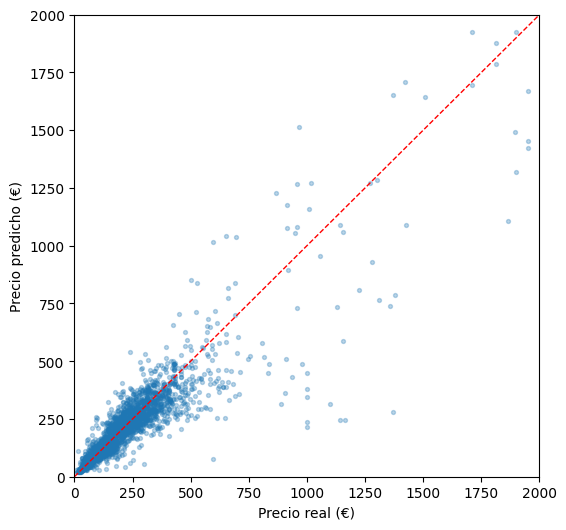

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=8, alpha=0.3)
lims = [0, 2000]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Precio real (€)")
plt.ylabel("Precio predicho (€)")
plt.xlim(lims)
plt.ylim(lims)

Para precios bajos y medios (hasta unos 500-750€) los puntos siguen bastante de cerca la diagonal. A partir de ahí, cada vez más puntos caen claramente por debajo: **el modelo tiende a subestimar los anuncios más caros**.

### 3.2 Distribución de los residuos

`residuals = predicho - real`. Un residuo negativo es una subestimación.

Media: -14.229089180670142
Mediana: 0.3095726055477428


(-500.0, 500.0)

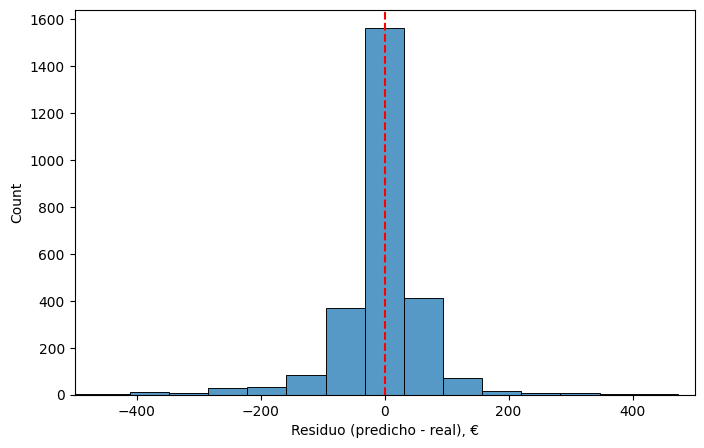

In [7]:
print("Media:", residuals.mean())
print("Mediana:", np.median(residuals))

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color="r", linestyle="--")
plt.xlabel("Residuo (predicho - real), €")
plt.xlim(-500, 500)

La mediana del residuo es prácticamente 0 (0.31€): para la mitad de los anuncios el modelo acierta casi exacto o incluso se queda un poco corto o largo por igual. Pero la **media es -14.23€**, bastante más negativa. Es la misma lección de la sección 4 del baseline: la media y la mediana cuentan historias distintas cuando hay una cola de errores grandes en una sola dirección. Aquí esa cola son las subestimaciones en los anuncios caros que ya se veían en el scatter.

### 3.3 ¿El sesgo depende del precio?

Se comprueba con dos vistas: un scatter de residuo contra precio real, y la media del residuo por quintiles de precio.

(0.0, 2000.0)

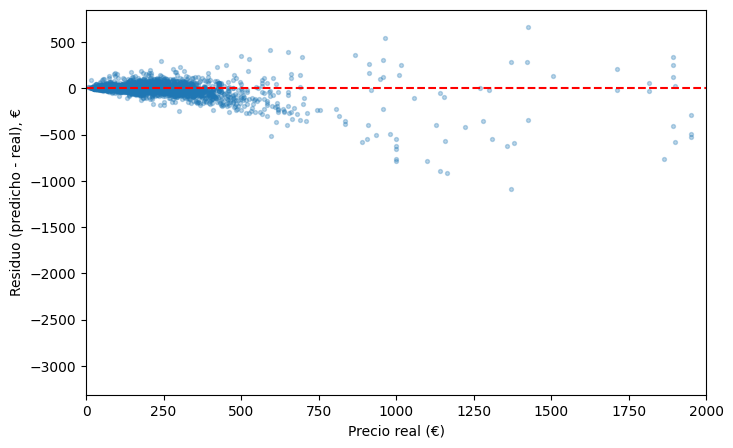

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, s=8, alpha=0.3)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Precio real (€)")
plt.ylabel("Residuo (predicho - real), €")
plt.xlim(0, 2000)

In [9]:
price_quintile = pd.qcut(y_test, 5)
pd.DataFrame({"residual": residuals}).groupby(price_quintile, observed=True)["residual"].agg(["mean", "median", "count"])

,mean,median,count
price,,,
"(6.879, 77.464]",7.712339,3.301282,531
"(77.464, 144.0]",6.944577,3.557315,533
"(144.0, 223.0]",10.496056,7.663503,529
"(223.0, 317.4]",2.615706,-2.024935,528
"(317.4, 7293.0]",-98.805579,-52.953296,531


Confirmado con números: en los cuatro quintiles de precio más bajos, el residuo medio está entre +2.6€ y +10.5€, prácticamente sin sesgo. En el quintil más caro (por encima de 317€) el residuo medio es **-98.8€** (mediana -53€) — el modelo subestima sistemáticamente los anuncios más caros, y de forma bastante más severa que el error "típico" que sugieren el MAE o el R² globales.

Es un patrón esperable dado cómo se entrenó el modelo: al optimizar sobre `log1p(price)`, un error relativo pequeño en la cola alta (donde `log1p` comprime mucho los valores) se traduce en un error absoluto grande al deshacer el logaritmo. El modelo global (R²=0.86, MAE=52€) sigue siendo bueno en conjunto, pero para un caso de uso donde importen especialmente los anuncios de precio alto, este sesgo sistemático es una limitación real a tener en cuenta, no solo una anécdota de un par de casos sueltos.

## 4. Errores por segmento

MAE/RMSE desglosados por `room_type`, por distrito y por rango de precio, para ver si el modelo falla más en algún grupo concreto en vez de fallar de forma pareja en todo el dataset.

### 4.1 Por `room_type`

Desde `02D_fe_listings_full.ipynb`, `room_type` quedó como 4 columnas one-hot (`room_type_Entire home/apt`, etc.), no como una única columna categórica. Se reconstruye con `idxmax` antes de agrupar.

In [10]:
room_type_cols = [c for c in feature_cols if c.startswith("room_type_")]
room_type_series = X_test[room_type_cols].idxmax(axis=1).str.replace("room_type_", "", regex=False)

rows = []
for rt in room_type_series.unique():
    mask = (room_type_series == rt).values
    scores = evaluate(y_test[mask], pred[mask], rt)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Entire home/apt,147.07,59.41,0.86,20.12,2066
Private room,80.19,27.31,0.65,21.15,552
Hotel room,30.26,24.14,0.91,10.61,16
Shared room,21.43,15.41,-1.72,30.84,18


`Entire home/apt` (2066 filas, la mayoría del test) tiene el RMSE/MAE más altos en euros, pero es esperable: es la categoría con precios más altos y más dispersos, así que sus errores absolutos también lo son. `Private room` tiene errores mucho más bajos en euros (MAE=27€) pero un R² más discreto (0.65). `Hotel room` (16 filas) y `Shared room` (18 filas) tienen muestras demasiado pequeñas para sacar conclusiones firmes — el R²=-1.72 de `Shared room` en concreto no significa que el modelo sea especialmente malo ahí, con 18 filas cualquier cosa puede pasar por azar.

### 4.2 Por distrito

In [11]:
district_cols = [c for c in feature_cols if c.startswith("district_")]
district_series = X_test[district_cols].idxmax(axis=1).str.replace("district_", "", regex=False)

rows = []
for d in district_series.unique():
    mask = (district_series == d).values
    scores = evaluate(y_test[mask], pred[mask], d)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2).sort_values("n", ascending=False)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Eixample,185.85,70.74,0.86,19.69,1040
Ciutat Vella,100.94,42.07,0.87,22.48,574
Gràcia,61.26,39.30,0.80,19.29,239
Sant Martí,81.60,42.10,0.84,21.09,239
Sants-Montjuïc,90.21,37.97,0.88,18.81,229
Sarrià-Sant Gervasi,54.42,36.16,0.75,22.42,147
Les Corts,48.86,32.31,0.79,18.89,69
Horta-Guinardó,139.30,57.86,0.51,19.04,62
Sant Andreu,23.41,16.99,0.93,16.54,27


En los distritos con más anuncios (`Eixample`, `Ciutat Vella`, `Gràcia`, `Sant Martí`, `Sants-Montjuïc`, todos con 229-1040 filas) el R² se mantiene entre 0.80 y 0.88, consistente con el resultado global. En los distritos con menos anuncios el resultado es más irregular: `Horta-Guinardó` (62 filas) baja a R²=0.51, y `Nou Barris` (26 filas) a R²=0.25. Tiene sentido: son las zonas donde el modelo ha visto menos ejemplos para aprender, así que generaliza peor ahí. No es necesariamente un problema del modelo en sí, sino una consecuencia directa de tener menos datos de esas zonas (26-62 anuncios en el barrio de Barcelona con menos oferta, frente a más de 1000 en Eixample).

### 4.3 Por rango de precio

Se completa lo que ya se vio en la sección 3.3 (solo con la media del residuo) con las métricas completas por quintil.

In [12]:
price_quintile = pd.qcut(y_test, 5)

rows = []
for q in price_quintile.cat.categories:
    mask = (price_quintile == q).values
    scores = evaluate(y_test[mask].values, pred[mask], str(q))
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
"(6.879, 77.464]",19.78,12.01,-0.36,25.45,531
"(77.464, 144.0]",30.99,20.52,-1.79,19.00,533
"(144.0, 223.0]",50.12,38.57,-3.39,21.11,529
"(223.0, 317.4]",54.53,39.40,-3.23,14.81,528
"(317.4, 7293.0]",289.96,150.57,0.80,21.37,531


El MAE crece de forma clara con el precio (12€ → 20€ → 38€ → 39€ → 150€ en el quintil más caro), coherente con la sección 3. El R² por quintil, en cambio, **no es una métrica útil aquí**: sale negativo en varios quintiles intermedios, no porque el modelo sea malo, sino porque al cortar por rangos de precio la variabilidad *dentro* de cada quintil es pequeña por construcción, y el R² depende de esa variabilidad para tener sentido. Para segmentar por precio conviene mirar MAE/RMSE en euros, no R².

## 5. Los peores casos

Los anuncios con mayor error absoluto, inspeccionados uno a uno: ¿son los Group Flats de la EDA? ¿anuncios con algún dato raro? ¿o errores sin patrón aparente?

### 5.1 Los 15 mayores errores absolutos

In [13]:
worst_idx = np.argsort(-np.abs(residuals))[:15]

cols_show = ["id", "price", "bedrooms", "accommodates", "minimum_nights", "bathrooms"]
worst = test_df.iloc[worst_idx][cols_show].copy()
worst["pred"] = pred[worst_idx]
worst["residual"] = residuals[worst_idx]
worst

,id,price,bedrooms,accommodates,minimum_nights,bathrooms,pred,residual
2624,1405062163700981309,7293.00,12.0,16,1.0,12.0,4168.799505,-3124.200495
1878,1406454143054865483,6151.00,14.0,16,1.0,13.0,3705.791370,-2445.208630
953,1305122407613584155,2443.00,4.0,10,1.0,4.0,1353.404965,-1089.595035
465,1183146635229347122,1369.41,2.0,4,1.0,1.0,281.570561,-1087.839439
735,1150686705476054239,3664.00,12.0,16,1.0,6.0,2578.865274,-1085.134726
51,1310155812196416061,2397.00,4.0,10,1.0,3.0,1317.562372,-1079.437628
698,1295850237784093567,3664.00,7.0,16,1.0,7.0,2636.418681,-1027.581319
2608,1249478654058479312,3766.00,8.0,16,1.0,8.0,2784.955460,-981.044540
1545,1476121021342726077,3264.00,12.0,16,1.0,8.0,2309.616425,-954.383575
2209,1574564096739283807,2716.00,8.0,16,1.0,4.0,1772.251567,-943.748433


### 5.2 El patrón principal: los Group Flats

**Los 15 son subestimaciones** (todos los residuos son negativos), y la mayoría tiene `bedrooms` entre 7 y 14 y `accommodates` entre 10 y 16 (el máximo de la plataforma). Son justo los "Group Flats" que ya aparecieron en la sección 8 de la EDA de `01D_eda_listings_full.ipynb`: pisos para grupos grandes en el Eixample, con precios de miles de euros. Confirma lo que ya se veía en la sección 3 y 4: el modelo se queda corto en la cola alta de precio, y estos son los casos concretos donde más se nota.

### 5.3 Un patrón distinto: anuncios pequeños con precio disparatado

Tres casos no encajan con lo anterior: `bedrooms` 1-2, `accommodates` 2-7 (nada que ver con un Group Flat), pero precios de 1140-1369€. Se investigan por separado.

In [14]:
anomaly_ids = [1183146635229347122, 1585662784156859250, 1675517721211179327]
cols_anomaly = [
    "id", "price", "bedrooms", "accommodates", "bathrooms", "minimum_nights",
    "has_license", "host_is_superhost", "review_scores_rating", "number_of_reviews",
]
test_df[test_df["id"].isin(anomaly_ids)][cols_anomaly]

,id,price,bedrooms,accommodates,bathrooms,minimum_nights,has_license,host_is_superhost,review_scores_rating,number_of_reviews
465,1183146635229347122,1369.41,2.0,4,1.0,1.0,True,False,NaN,0
1771,1585662784156859250,1163.00,2.0,7,1.0,1.0,True,False,NaN,0
2270,1675517721211179327,1140.50,1.0,2,1.0,2.0,True,False,5.0,1


Los tres tienen **0 o 1 reviews**, pese a tener licencia y ser anuncios normales por lo demás (2-4-7 huéspedes, 1-2 dormitorios). Un piso de 2 dormitorios a 1369€/noche no es un precio de mercado creíble para ese tamaño, y la falta casi total de reviews encaja con una explicación habitual en plataformas de alquiler: un host pone un precio disparatadamente alto para que en la práctica nadie reserve, sin llegar a desactivar el anuncio del todo (a veces para "cerrarlo" temporalmente, o para probar si alguien pica). Si es así, el modelo no está fallando por no entender el alojamiento, está fallando porque ese número no refleja un precio real de mercado. No hay forma de confirmarlo con los datos disponibles, pero es una hipótesis más plausible que asumir que el modelo simplemente no sabe valorar apartamentos pequeños.

En conjunto, los peores errores del modelo tienen dos causas distintas: la cola alta de precio genuina (Group Flats, donde el modelo subestima de forma sistemática) y un puñado de precios que probablemente no son de mercado real. Ninguna de las dos se soluciona con más ajuste de hiperparámetros; la primera necesitaría tratar la cola alta de otra forma (p. ej. un modelo separado para grupos grandes, o pesos distintos en el entrenamiento), y la segunda necesitaría poder identificar y filtrar precios no realistas antes de entrenar.

## 6. Revisar la fuga pendiente de `neighbourhood_price_encoded`

Desde `02D_fe_listings.ipynb` quedó documentado (sin corregir) que esta columna se calculó con todo el dataset, no solo con train. Aquí se comprueba si recalcularla solo con train cambia el resultado de forma apreciable, para saber si de verdad hacía falta arreglarlo o si el impacto era tan pequeño como se estimó.

### 6.1 Recuperar el barrio original

`neighbourhood_cleansed` (el texto original del barrio) ya no está en `listings_full_features.csv`, se descartó en `02D_fe_listings_full.ipynb` una vez calculada la codificación. Se recupera haciendo `merge` por `id` con `listings_full_clean.csv` (la salida de `01D_eda_listings_full.ipynb`, antes de feature engineering).

In [15]:
train_df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_train.csv")

full_clean = pd.read_csv(
    "/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_full_clean.csv",
    usecols=["id", "neighbourhood_cleansed"],
)

train_df = train_df.merge(full_clean, on="id", how="left")
test_df = test_df.merge(full_clean, on="id", how="left")

train_df["neighbourhood_cleansed"].isnull().sum(), test_df["neighbourhood_cleansed"].isnull().sum()

(np.int64(0), np.int64(0))

### 6.2 Recalcular la codificación solo con train

Mismo target encoding suavizado que en `02D_fe_listings_full.ipynb` (suavizado=10), pero calculado únicamente con `train_df`, y aplicado después a ambos conjuntos. Los barrios de test que no aparecieran en train (no es el caso aquí, pero podría pasar) se rellenan con la media global de train.

In [16]:
global_mean_price = train_df["price"].mean()
neigh_stats = train_df.groupby("neighbourhood_cleansed")["price"].agg(["mean", "count"])
smoothing = 10
smoothed_mean = (neigh_stats["count"] * neigh_stats["mean"] + smoothing * global_mean_price) / (neigh_stats["count"] + smoothing)

train_df["neighbourhood_price_encoded_fixed"] = train_df["neighbourhood_cleansed"].map(smoothed_mean)
test_df["neighbourhood_price_encoded_fixed"] = (
    test_df["neighbourhood_cleansed"].map(smoothed_mean).fillna(global_mean_price)
)

diff = (train_df["neighbourhood_price_encoded"] - train_df["neighbourhood_price_encoded_fixed"]).abs()
print("diferencia media entre la codificación original y la corregida:", diff.mean())
print("diferencia máxima:", diff.max())

diferencia media entre la codificación original y la corregida: 6.460861872748055
diferencia máxima: 35.8978843988599


### 6.3 Reentrenar con la versión corregida

Mismos hiperparámetros que el modelo final (guardados en `metadata["best_params"]`), sustituyendo solo esa columna, para que la comparación sea limpia: si el resultado cambia, es por la codificación, no por ningún otro cambio.

In [17]:
from sklearn.ensemble import HistGradientBoostingRegressor

feature_cols_fixed = [
    c if c != "neighbourhood_price_encoded" else "neighbourhood_price_encoded_fixed"
    for c in feature_cols
]

X_train_fixed = train_df[feature_cols_fixed].copy()
X_train_fixed.columns = feature_cols
y_train = train_df["price"].copy()
X_test_fixed = test_df[feature_cols_fixed].copy()
X_test_fixed.columns = feature_cols

for df_ in (X_train_fixed, X_test_fixed):
    bool_cols = df_.select_dtypes(include="bool").columns
    df_[bool_cols] = df_[bool_cols].astype(int)

model_fixed = HistGradientBoostingRegressor(random_state=42, **metadata["best_params"])
model_fixed.fit(X_train_fixed, np.log1p(y_train))
pred_fixed = np.expm1(model_fixed.predict(X_test_fixed))

pd.DataFrame([
    metadata["test_metrics"],
    evaluate(y_test, pred_fixed, "Hist Gradient Boosting (encoding corregido)"),
]).set_index("modelo")

,RMSE,MAE,R2,MAPE
modelo,,,,
Hist Gradient Boosting (final),134.900336,52.216665,0.858529,20.351604
Hist Gradient Boosting (encoding corregido),142.410955,53.879607,0.842337,20.743428


### 6.4 ¿Importaba de verdad?

La codificación cambia poco (diferencia media de 6.46€, máxima de 35.90€ en algún barrio), y el resultado del modelo empeora ligeramente al corregirla: R² de 0.86 a 0.84, RMSE de 135€ a 142€, MAE de 52€ a 54€. Es una diferencia real pero pequeña, del orden del 5-6% en RMSE/MAE, no algo que cambie ninguna conclusión de las secciones anteriores (el patrón de subestimación en precios altos, el peso de `minimum_nights`, etc. no dependen de esto).

Conclusión: la fuga era real, no una falsa alarma, pero de impacto menor. El **R²=0.86 guardado en `models/model_metadata.json` está ligeramente inflado**; el número honesto, sin fuga, es más cercano a **R²=0.84**. Queda decisión de negocio, no técnica, si merece la pena regenerar `02D_fe_listings_full.ipynb` y volver a entrenar con la versión corregida, o aceptar esta pequeña discrepancia documentada.

## 7. Conclusiones

Resumen de si el modelo se comporta de forma consistente en todo el dataset o tiene puntos débiles claros, y si la fuga pendiente resultó relevante o no.

### Veredicto general

El modelo cargado reproduce exactamente las métricas con las que se guardó, así que todo el análisis siguiente parte de una base fiable. En conjunto, **es un modelo sólido para la mayoría de anuncios** (precio bajo y medio, distritos con buena representación), pero tiene puntos débiles claros y ya identificados, no solo un número de R² global.

### Lo que funciona bien

- Buen ajuste en los cuatro quintiles de precio más bajos (sesgo casi nulo, entre +2.6€ y +10.5€ de media).
- R² entre 0.80 y 0.88 en los distritos y tipos de alojamiento con más muestra (`Eixample`, `Ciutat Vella`, `Gràcia`, `Sant Martí`, `Sants-Montjuïc`; `Entire home/apt`).
- Sin señales de sobreajuste (train y test se comportan de forma consistente, ya visto en `03_model_training.ipynb`).

### Limitaciones identificadas

1. **Subestima sistemáticamente los anuncios más caros**: residuo medio de -98.8€ en el quintil superior de precio, frente a un sesgo casi nulo en el resto. Los "Group Flats" (pisos para grupos grandes) concentran la mayoría de los peores errores.
2. **Se degrada en segmentos con poca muestra**: `Horta-Guinardó` (R²=0.51, 62 filas) y `Nou Barris` (R²=0.25, 26 filas) van claramente peor que los distritos grandes, probablemente por falta de ejemplos para aprender, no por una limitación del modelo en sí.
3. **Un puñado de precios que probablemente no son de mercado real**: anuncios pequeños con precio disparatado y 0-1 reviews, posibles "precios de cierre". El modelo no puede aprender a predecir bien algo que no responde a una lógica de mercado normal.
4. **La fuga de `neighbourhood_price_encoded` era real**: el R²=0.86 guardado está algo inflado; el valor honesto sin fuga es ~0.84. Impacto menor, pero hay que tenerlo presente en cualquier reporte del rendimiento del modelo hacia fuera.

### Recomendaciones

**De cara a un producto real** (recordando la conversación inicial sobre el caso de uso): dar un **rango de precio, no un número único**, y sobre todo avisar explícitamente cuando el input se parezca a un caso de baja confianza: `bedrooms`/`accommodates` muy altos (zona de los Group Flats), o un barrio con poca representación en los datos. Ahí el modelo es objetivamente menos fiable, y un usuario debería saberlo.

**De cara a mejorar el modelo, no aplicado aquí**:
- Corregir de forma definitiva `neighbourhood_price_encoded` en `02D_fe_listings_full.ipynb` (recalcular con train-only, ya validado en la sección 6) y volver a entrenar.
- Tratar la cola alta de precio de forma distinta: un modelo separado para alojamientos grandes, o dar más peso a esos casos durante el entrenamiento.
- Explorar si se pueden filtrar o marcar los anuncios con precio sin actividad real (0 reviews y precio extremo) antes de entrenar, en vez de dejar que el modelo intente aprender de ruido.